In [8]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from scipy import linalg
import time

np.random.seed(42)
tf.random.set_seed(42)

In [9]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(-1, 784)

In [10]:
init = tf.keras.initializers.GlorotNormal(seed=42)

def build_generator():
    return tf.keras.Sequential([
        tf.keras.layers.Input((100,)),
        tf.keras.layers.Dense(256, activation='relu', kernel_initializer=init),
        tf.keras.layers.Dense(512, activation='relu', kernel_initializer=init),
        tf.keras.layers.Dense(1024, activation='relu', kernel_initializer=init),
        tf.keras.layers.Dense(784, activation='tanh', kernel_initializer=init),
    ])

def build_discriminator():
    return tf.keras.Sequential([
        tf.keras.layers.Input((784,)),
        tf.keras.layers.Dense(1024, kernel_initializer=init),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(512, kernel_initializer=init),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, kernel_initializer=init),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid', kernel_initializer=init),
    ])

In [11]:
bce = tf.keras.losses.BinaryCrossentropy()

def d_loss_fn(real_out, fake_out):
    real_loss = bce(tf.ones_like(real_out), real_out)
    fake_loss = bce(tf.zeros_like(fake_out), fake_out)
    return real_loss + fake_loss

def g_loss_saturating(fake_out):
    return tf.reduce_mean(tf.math.log(1 - fake_out + 1e-8))

def g_loss_nonsaturating(fake_out):
    return bce(tf.ones_like(fake_out), fake_out)

In [12]:
FIXED_NOISE = tf.random.normal((25, 100), seed=42)

def plot_grid(images, title):
    images = (images.numpy().reshape(-1, 28, 28) + 1) / 2.0
    fig, axes = plt.subplots(5, 5, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], cmap='gray')
        ax.axis('off')
    fig.suptitle(title)
    plt.show()

def make_optimizer(kind, lr=2e-4):
    if kind == 'adam':
        return tf.keras.optimizers.Adam(lr, beta_1=0.5, beta_2=0.999)
    if kind == 'sgd':
        return tf.keras.optimizers.SGD(lr)
    if kind == 'rmsprop':
        return tf.keras.optimizers.RMSprop(lr)
    if kind == 'adamw':
        return tf.keras.optimizers.AdamW(lr, beta_1=0.5, beta_2=0.999)
    raise ValueError(kind)

In [13]:
def train_gan(g_loss_fn, optimizer_kind='adam', lr=2e-4, k=1, epochs=50,
              batch_size=128, snapshot_epochs=(10, 20, 30, 50)):
    gen = build_generator()
    disc = build_discriminator()
    g_opt = make_optimizer(optimizer_kind, lr)
    d_opt = make_optimizer(optimizer_kind, lr)

    g_losses, d_losses = [], []
    snapshots = {}

    n_batches = x_train.shape[0] // batch_size

    for epoch in range(1, epochs + 1):
        idx = np.random.permutation(x_train.shape[0])
        epoch_g_loss, epoch_d_loss = [], []
        for b in range(n_batches):
            real_images = x_train[idx[b * batch_size:(b + 1) * batch_size]]
            real_images = tf.convert_to_tensor(real_images, dtype=tf.float32)
            bs = tf.shape(real_images)[0]

            d_loss_val = None
            for _ in range(k):
                noise = tf.random.normal((bs, 100))
                with tf.GradientTape() as d_tape:
                    fake_images = gen(noise, training=True)
                    real_out = disc(real_images, training=True)
                    fake_out = disc(fake_images, training=True)
                    d_loss_val = d_loss_fn(real_out, fake_out)
                d_grads = d_tape.gradient(d_loss_val, disc.trainable_variables)
                d_opt.apply_gradients(zip(d_grads, disc.trainable_variables))

            noise = tf.random.normal((bs, 100))
            with tf.GradientTape() as g_tape:
                fake_images = gen(noise, training=True)
                fake_out = disc(fake_images, training=True)
                g_loss_val = g_loss_fn(fake_out)
            g_grads = g_tape.gradient(g_loss_val, gen.trainable_variables)
            g_opt.apply_gradients(zip(g_grads, gen.trainable_variables))

            epoch_g_loss.append(float(g_loss_val))
            epoch_d_loss.append(float(d_loss_val))

        g_losses.append(np.mean(epoch_g_loss))
        d_losses.append(np.mean(epoch_d_loss))
        print(f"Epoch {epoch}/{epochs}  G_loss={g_losses[-1]:.4f}  D_loss={d_losses[-1]:.4f}")

        if epoch in snapshot_epochs:
            snapshots[epoch] = gen(FIXED_NOISE, training=False)

    return gen, disc, g_losses, d_losses, snapshots

In [15]:
gen_sat, disc_sat, g_losses_sat, d_losses_sat, snaps_sat = train_gan(
    g_loss_saturating, optimizer_kind='adam', lr=2e-4, k=1, epochs=5)

Epoch 1/5  G_loss=-0.2327  D_loss=0.6562
Epoch 2/5  G_loss=-0.0099  D_loss=0.0657
Epoch 3/5  G_loss=-0.0002  D_loss=0.0012
Epoch 4/5  G_loss=0.0000  D_loss=0.0000
Epoch 5/5  G_loss=0.0000  D_loss=0.0000


In [16]:
for epoch, imgs in snaps_sat.items():
    plot_grid(imgs, f"Saturating GAN - Epoch {epoch}")

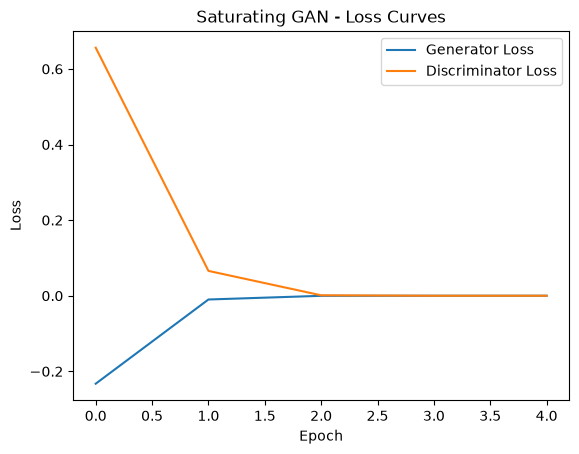

In [17]:
plt.figure()
plt.plot(g_losses_sat, label="Generator Loss")
plt.plot(d_losses_sat, label="Discriminator Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Saturating GAN - Loss Curves")
plt.legend(); plt.show()

In [24]:
def get_inception_features(images_flat):
    imgs = images_flat.reshape(-1, 28, 28, 1)
    imgs = (imgs + 1) / 2.0
    imgs = tf.image.resize(imgs, (75, 75))
    imgs = tf.image.grayscale_to_rgb(imgs)
    imgs = tf.keras.applications.inception_v3.preprocess_input(imgs * 255.0)
    features = inception_model.predict(imgs, verbose=0)
    return features

def get_inception_probs(images_flat):
    imgs = images_flat.reshape(-1, 28, 28, 1)
    imgs = (imgs + 1) / 2.0
    imgs = tf.image.resize(imgs, (75, 75))
    imgs = tf.image.grayscale_to_rgb(imgs)
    imgs = tf.keras.applications.inception_v3.preprocess_input(imgs * 255.0)
    probs = inception_full_model.predict(imgs, verbose=0)
    return probs

inception_model = tf.keras.applications.InceptionV3(
    include_top=False, pooling='avg', input_shape=(75, 75, 3), weights='imagenet')
inception_full_model = tf.keras.applications.InceptionV3(
    include_top=False, input_shape=(75, 75, 3), weights='imagenet')

def compute_fid(real_flat, fake_flat):
    real_feat = get_inception_features(real_flat)
    fake_feat = get_inception_features(fake_flat)
    mu1, sigma1 = real_feat.mean(axis=0), np.cov(real_feat, rowvar=False)
    mu2, sigma2 = fake_feat.mean(axis=0), np.cov(fake_feat, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def compute_is(fake_flat, splits=5):
    probs = get_inception_probs(fake_flat)
    n = probs.shape[0]
    scores = []
    for i in range(splits):
        part = probs[i * (n // splits): (i + 1) * (n // splits)]
        py = np.mean(part, axis=0)
        kl = part * (np.log(part + 1e-8) - np.log(py + 1e-8))
        kl = np.mean(np.sum(kl, axis=1))
        scores.append(np.exp(kl))
    return np.mean(scores), np.std(scores)

In [25]:
real_sample = x_train[np.random.choice(len(x_train), 500, replace=False)]
fake_sample = gen_sat(tf.random.normal((500, 100)), training=False).numpy()

fid_sat = compute_fid(real_sample, fake_sample)
is_mean_sat, is_std_sat = compute_is(fake_sample)
print("Saturating GAN - FID:", fid_sat, "IS:", is_mean_sat, "+/-", is_std_sat)

C:\Users\Reaper\AppData\Local\Temp\ipykernel_14568\2530379064.py:30: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
C:\Users\Reaper\AppData\Local\Temp\ipykernel_14568\2530379064.py:30: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


Saturating GAN - FID: 1017.4982227595222 IS: 1.0131216 +/- 0.00041337413


In [26]:
gen_ns, disc_ns, g_losses_ns, d_losses_ns, snaps_ns = train_gan(
    g_loss_nonsaturating, optimizer_kind='adam', lr=2e-4, k=1, epochs=5)

Epoch 1/5  G_loss=2.2701  D_loss=0.6571
Epoch 2/5  G_loss=4.5834  D_loss=0.3619
Epoch 3/5  G_loss=4.2461  D_loss=0.4121
Epoch 4/5  G_loss=3.9942  D_loss=0.4326
Epoch 5/5  G_loss=3.9225  D_loss=0.4067


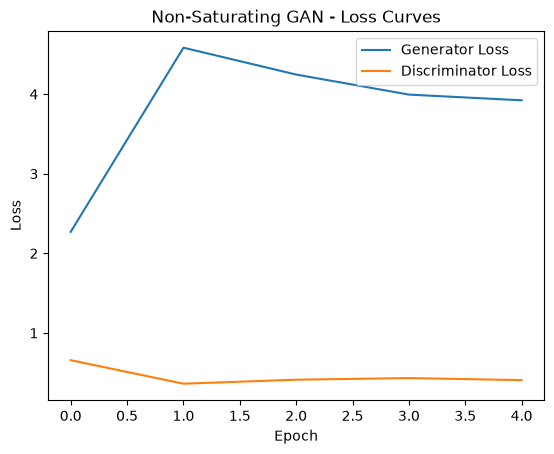

C:\Users\Reaper\AppData\Local\Temp\ipykernel_14568\2530379064.py:30: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
C:\Users\Reaper\AppData\Local\Temp\ipykernel_14568\2530379064.py:30: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


Non-Saturating GAN - FID: 635.6590159738411 IS: 1.0675919 +/- 0.001322906


In [27]:
for epoch, imgs in snaps_ns.items():
    plot_grid(imgs, f"Non-Saturating GAN - Epoch {epoch}")

plt.figure()
plt.plot(g_losses_ns, label="Generator Loss")
plt.plot(d_losses_ns, label="Discriminator Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Non-Saturating GAN - Loss Curves")
plt.legend(); plt.show()

fake_sample_ns = gen_ns(tf.random.normal((500, 100)), training=False).numpy()
fid_ns = compute_fid(real_sample, fake_sample_ns)
is_mean_ns, is_std_ns = compute_is(fake_sample_ns)
print("Non-Saturating GAN - FID:", fid_ns, "IS:", is_mean_ns, "+/-", is_std_ns)

In [32]:
print("Metric            | Saturating | Non-Saturating")
print("Final G loss      |", g_losses_sat[-1], "|", g_losses_ns[-1])
print("Final D loss      |", d_losses_sat[-1], "|", d_losses_ns[-1])
print("FID               |", fid_sat, "|", fid_ns)
print("IS                |", is_mean_sat, "|", is_mean_ns)
"""
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(((snaps_sat[5].numpy().reshape(-1, 28, 28)[0] + 1) / 2), cmap='gray')
axes[0].set_title("Saturating"); axes[0].axis('off')
axes[1].imshow(((snaps_ns[5].numpy().reshape(-1, 28, 28)[0] + 1) / 2), cmap='gray')
axes[1].set_title("Non-Saturating"); axes[1].axis('off')
plt.show()
"""

Metric            | Saturating | Non-Saturating
Final G loss      | 0.0 | 3.922504842026621
Final D loss      | 1.6334353538288951e-06 | 0.40673310121791995
FID               | 1017.4982227595222 | 635.6590159738411
IS                | 1.0131216 | 1.0675919


'\nfig, axes = plt.subplots(1, 2, figsize=(8, 4))\naxes[0].imshow(((snaps_sat[5].numpy().reshape(-1, 28, 28)[0] + 1) / 2), cmap=\'gray\')\naxes[0].set_title("Saturating"); axes[0].axis(\'off\')\naxes[1].imshow(((snaps_ns[5].numpy().reshape(-1, 28, 28)[0] + 1) / 2), cmap=\'gray\')\naxes[1].set_title("Non-Saturating"); axes[1].axis(\'off\')\nplt.show()\n'

In [34]:
optimizer_results = {}
for opt_kind in ['sgd', 'rmsprop', 'adam', 'adamw']:
    print("\nTraining with optimizer:", opt_kind)
    g, d, gl, dl, snaps = train_gan(g_loss_nonsaturating, optimizer_kind=opt_kind,
                                     lr=2e-4, k=1, epochs=3, snapshot_epochs=(3,))
    optimizer_results[opt_kind] = {"g_loss": gl, "d_loss": dl, "gen": g, "snap": snaps[3]}


Training with optimizer: sgd
Epoch 1/3  G_loss=0.7021  D_loss=0.7953
Epoch 2/3  G_loss=0.8292  D_loss=0.6144
Epoch 3/3  G_loss=0.9084  D_loss=0.5524

Training with optimizer: rmsprop
Epoch 1/3  G_loss=1.1574  D_loss=1.0323
Epoch 2/3  G_loss=1.5697  D_loss=1.1255
Epoch 3/3  G_loss=1.8588  D_loss=1.0247

Training with optimizer: adam
Epoch 1/3  G_loss=2.2964  D_loss=0.6529
Epoch 2/3  G_loss=4.5370  D_loss=0.3559
Epoch 3/3  G_loss=4.8309  D_loss=0.3573

Training with optimizer: adamw
Epoch 1/3  G_loss=2.2965  D_loss=0.6578
Epoch 2/3  G_loss=4.5878  D_loss=0.3510
Epoch 3/3  G_loss=4.6972  D_loss=0.3879


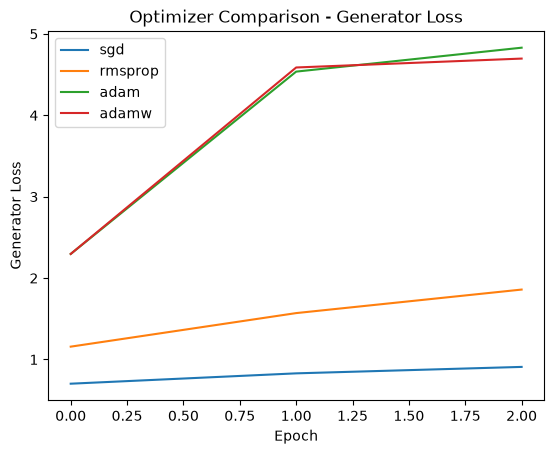

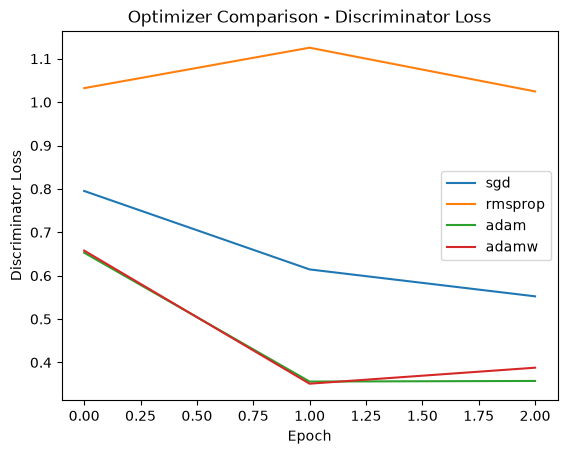

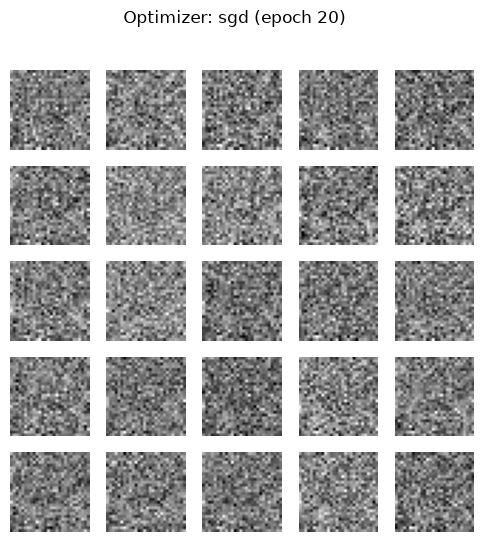

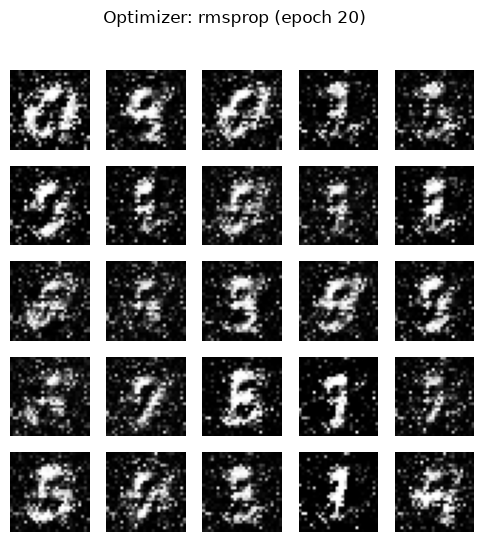

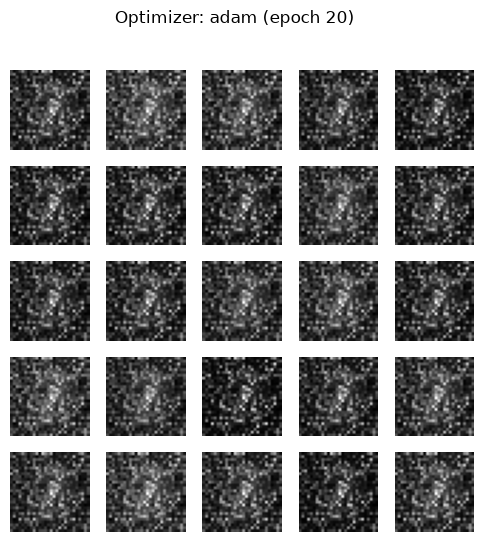

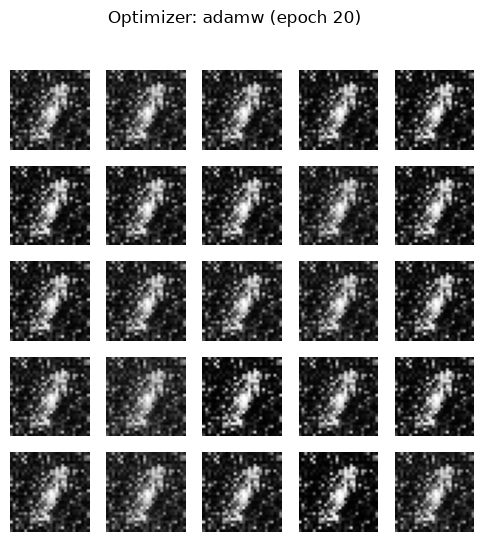

Optimizer | Final G loss | Final D loss | Loss variance (last 5 epochs, G)
sgd 0.9084247149463393 0.5523852889354413 0.007220780071025075
rmsprop 1.8588313427236345 1.0247173244372392 0.08285568301389402
adam 4.830931140316857 0.3573147726810386 1.2812302686215744
adamw 4.697172838143813 0.38786650829526603 1.224974176766321


In [35]:
plt.figure()
for opt_kind, r in optimizer_results.items():
    plt.plot(r["g_loss"], label=opt_kind)
plt.xlabel("Epoch"); plt.ylabel("Generator Loss")
plt.title("Optimizer Comparison - Generator Loss")
plt.legend(); plt.show()

plt.figure()
for opt_kind, r in optimizer_results.items():
    plt.plot(r["d_loss"], label=opt_kind)
plt.xlabel("Epoch"); plt.ylabel("Discriminator Loss")
plt.title("Optimizer Comparison - Discriminator Loss")
plt.legend(); plt.show()

for opt_kind, r in optimizer_results.items():
    plot_grid(r["snap"], f"Optimizer: {opt_kind} (epoch 20)")

print("Optimizer | Final G loss | Final D loss | Loss variance (last 5 epochs, G)")
for opt_kind, r in optimizer_results.items():
    print(opt_kind, r["g_loss"][-1], r["d_loss"][-1], np.var(r["g_loss"][-5:]))

In [36]:
k_results = {}
for k in [1, 2, 3]:
    print("\nTraining with k =", k)
    g, d, gl, dl, snaps = train_gan(g_loss_nonsaturating, optimizer_kind='adam',
                                     lr=2e-4, k=k, epochs=3, snapshot_epochs=(3,))
    k_results[k] = {"g_loss": gl, "d_loss": dl, "gen": g, "snap": snaps[3]}


Training with k = 1
Epoch 1/3  G_loss=2.2404  D_loss=0.6709
Epoch 2/3  G_loss=4.6313  D_loss=0.3232
Epoch 3/3  G_loss=4.6761  D_loss=0.3719

Training with k = 2
Epoch 1/3  G_loss=4.0423  D_loss=0.2169
Epoch 2/3  G_loss=4.3481  D_loss=0.1936
Epoch 3/3  G_loss=4.1585  D_loss=0.1951

Training with k = 3
Epoch 1/3  G_loss=4.5849  D_loss=0.1369
Epoch 2/3  G_loss=3.7751  D_loss=0.1711
Epoch 3/3  G_loss=3.4041  D_loss=0.2233


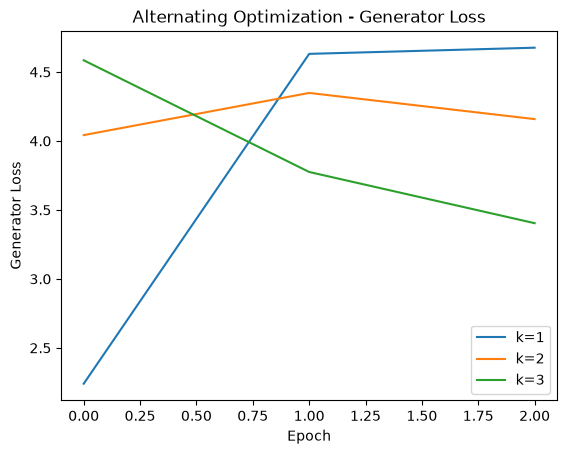

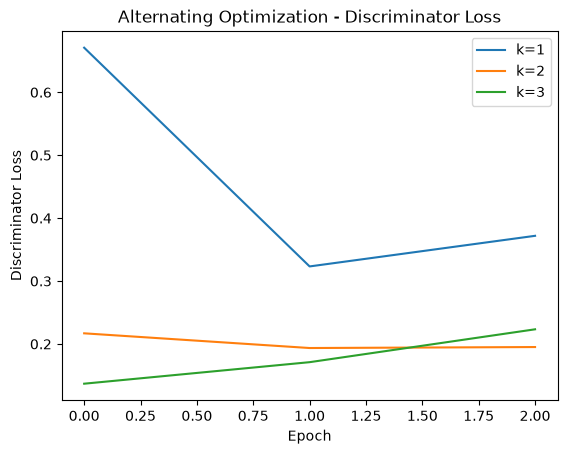

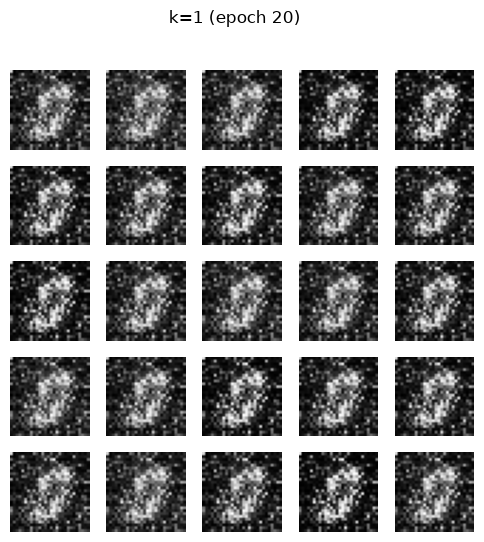

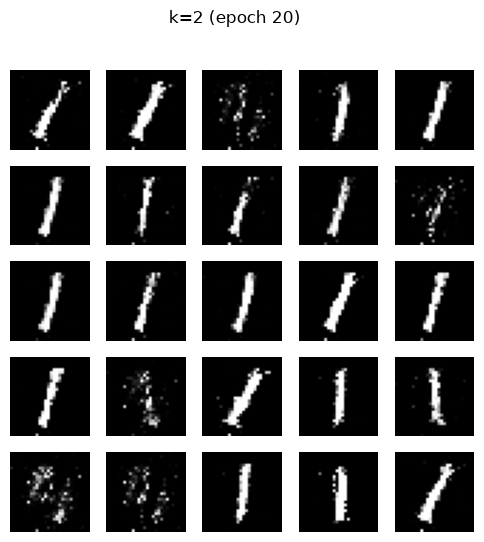

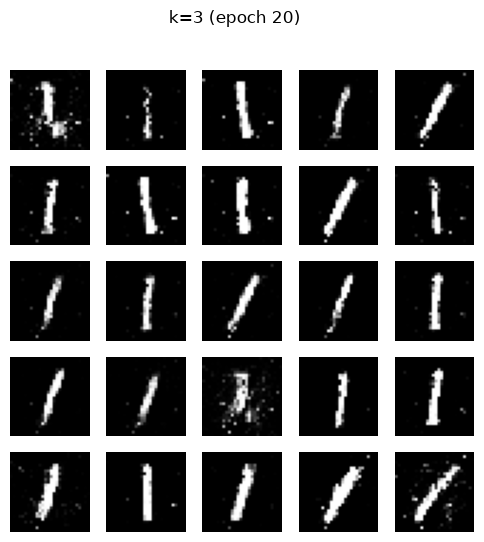

k | Final G loss | Final D loss
1 4.676053257579477 0.3718845523002311
2 4.158507297436397 0.1951081712021787
3 3.4040711211343098 0.2232948131302101


In [37]:
plt.figure()
for k, r in k_results.items():
    plt.plot(r["g_loss"], label=f"k={k}")
plt.xlabel("Epoch"); plt.ylabel("Generator Loss")
plt.title("Alternating Optimization - Generator Loss")
plt.legend(); plt.show()

plt.figure()
for k, r in k_results.items():
    plt.plot(r["d_loss"], label=f"k={k}")
plt.xlabel("Epoch"); plt.ylabel("Discriminator Loss")
plt.title("Alternating Optimization - Discriminator Loss")
plt.legend(); plt.show()

for k, r in k_results.items():
    plot_grid(r["snap"], f"k={k} (epoch 20)")

print("k | Final G loss | Final D loss")
for k, r in k_results.items():
    print(k, r["g_loss"][-1], r["d_loss"][-1])